In [2]:
# Import the necessary library
import pandas as pd

# Load the CSV file
df = pd.read_csv("ab_data.csv")

# Display the first few rows
df.head()


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [8]:
# To make sure all the control group are seeing the old page and viceversa
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [11]:
# Count the number of users that appear multiple times
session_counts = df['user_id'].value_counts(ascending=False)
multi_users = session_counts[session_counts > 1].count()

# Print the result properly
print(f'There are {multi_users} users that appear multiple times in the dataset')

# Alternatively, if you want to split the string over multiple lines, use one of the methods above


There are 3894 users that appear multiple times in the dataset


In [12]:
users_to_drop = session_counts[session_counts > 1].index
df = df[~df['user_id'].isin(users_to_drop)]
print(f'The updated dataset now has {df.shape[0]} entries')

The updated dataset now has 286690 entries


In [14]:
# Calculate the required sample size
import statsmodels.stats.api as sms
from math import ceil

effect_size = sms.proportion_effectsize(0.13, 0.15)  # Effect size calculation based on expected rates (13% and 15%)
required_n = sms.NormalIndPower().solve_power(effect_size, power=0.8, alpha=0.05, ratio=1)
required_n = ceil(required_n)  # Round up to the nearest whole number

print(f'The required sample size per group is: {required_n}')

# Sample the required number of observations from each group
control_sample = df[df['group'] == 'control'].sample(n=required_n, random_state=22)
treatment_sample = df[df['group'] == 'treatment'].sample(n=required_n, random_state=22)

# Combine the control and treatment samples into one DataFrame
ab_test = pd.concat([control_sample, treatment_sample], axis=0)
ab_test.reset_index(drop=True, inplace=True)

# Display the combined DataFrame
ab_test.head()

The required sample size per group is: 4720


,user_id,timestamp,group,landing_page,converted
0,763854,2017-01-21 03:43:17.188315,control,old_page,0
1,690555,2017-01-18 06:38:13.079449,control,old_page,0
2,861520,2017-01-06 21:13:40.044766,control,old_page,0
3,630778,2017-01-05 16:42:36.995204,control,old_page,0
4,656634,2017-01-04 15:31:21.676130,control,old_page,0


In [15]:
ab_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9440 entries, 0 to 9439
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       9440 non-null   int64 
 1   timestamp     9440 non-null   object
 2   group         9440 non-null   object
 3   landing_page  9440 non-null   object
 4   converted     9440 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 368.9+ KB


In [17]:
import numpy as np
import scipy.stats as stats

# Group by 'group' and calculate conversion rates with standard deviation and standard error
conversion_rates = ab_test.groupby('group')['converted']

# Define functions for standard deviation and standard error
std_p = lambda x: np.std(x, ddof=0)  # Std. deviation of the proportion
se_p = lambda x: stats.sem(x, ddof=0)  # Std. error of the proportion (std / sqrt(n))

# Aggregate the data to include mean, standard deviation, and standard error
conversion_rates = conversion_rates.agg([np.mean, std_p, se_p])

# Rename columns for clarity
conversion_rates.columns = ['conversion_rate', 'std_deviation', 'std_error']

# Format the conversion rates DataFrame to three decimal places
conversion_rates.style.format('{:.3f}')


<ipython-input-17-e0416d486bb9>:12: FutureWarning: The provided callable <function mean at 0x79ae9ccd3d00> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  conversion_rates = conversion_rates.agg([np.mean, std_p, se_p])


,conversion_rate,std_deviation,std_error
group,,,
control,0.123,0.329,0.005
treatment,0.126,0.331,0.005


<ipython-input-19-cdbc8e974780>:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x=ab_test['group'], y=ab_test['converted'], ci=False)


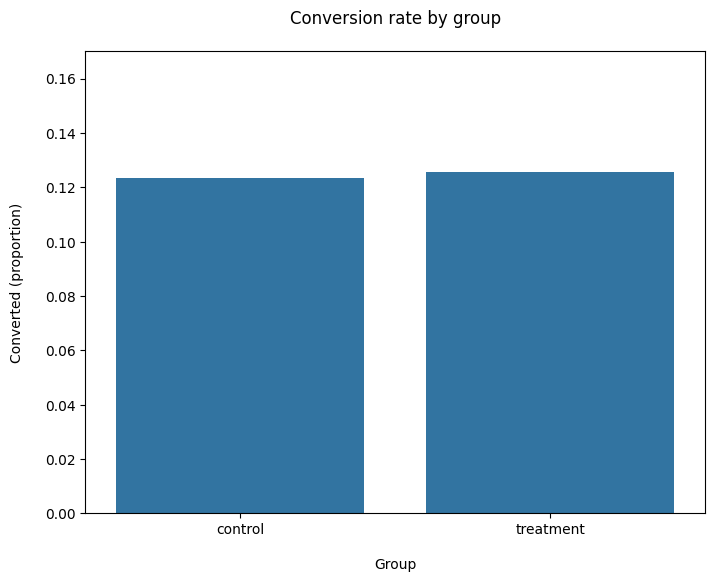

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the conversion rates by group
plt.figure(figsize=(8, 6))
sns.barplot(x=ab_test['group'], y=ab_test['converted'], ci=False)
plt.ylim(0, 0.17)
plt.title('Conversion rate by group', pad=20)
plt.xlabel('Group', labelpad=15)
plt.ylabel('Converted (proportion)', labelpad=15)
plt.show()

In [21]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Extract results for control and treatment groups
control_results = ab_test[ab_test['group'] == 'control']['converted']
treatment_results = ab_test[ab_test['group'] == 'treatment']['converted']

# Count the number of observations in each group
n_con = control_results.count()
n_treat = treatment_results.count()

# Summarize the successes (conversions) in each group
successes = [control_results.sum(), treatment_results.sum()]
nobs = [n_con, n_treat]

# Perform the z-test for proportions
z_stat, pval = proportions_ztest(successes, nobs=nobs)

# Calculate the confidence intervals for each group
(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(successes, nobs=nobs, alpha=0.05)

# Print the results
print(f'z statistic: {z_stat:.2f}')
print(f'p-value: {pval:.3f}')
print(f'ci 95% for control group: [{lower_con:.3f}, {upper_con:.3f}]')
print(f'ci 95% for treatment group: [{lower_treat:.3f}, {upper_treat:.3f}]')


z statistic: -0.34
p-value: 0.732
ci 95% for control group: [0.114, 0.133]
ci 95% for treatment group: [0.116, 0.135]
